In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [2]:
scores = np.load("/content/feature_importances.npy")
idx = np.load("/content/feature_ranking_idx.npy")

In [3]:
352+16

368

In [4]:
vertic = np.array([]*35)
for i in range(len(vertic)):
  vertic[i] = 368*(i+1)

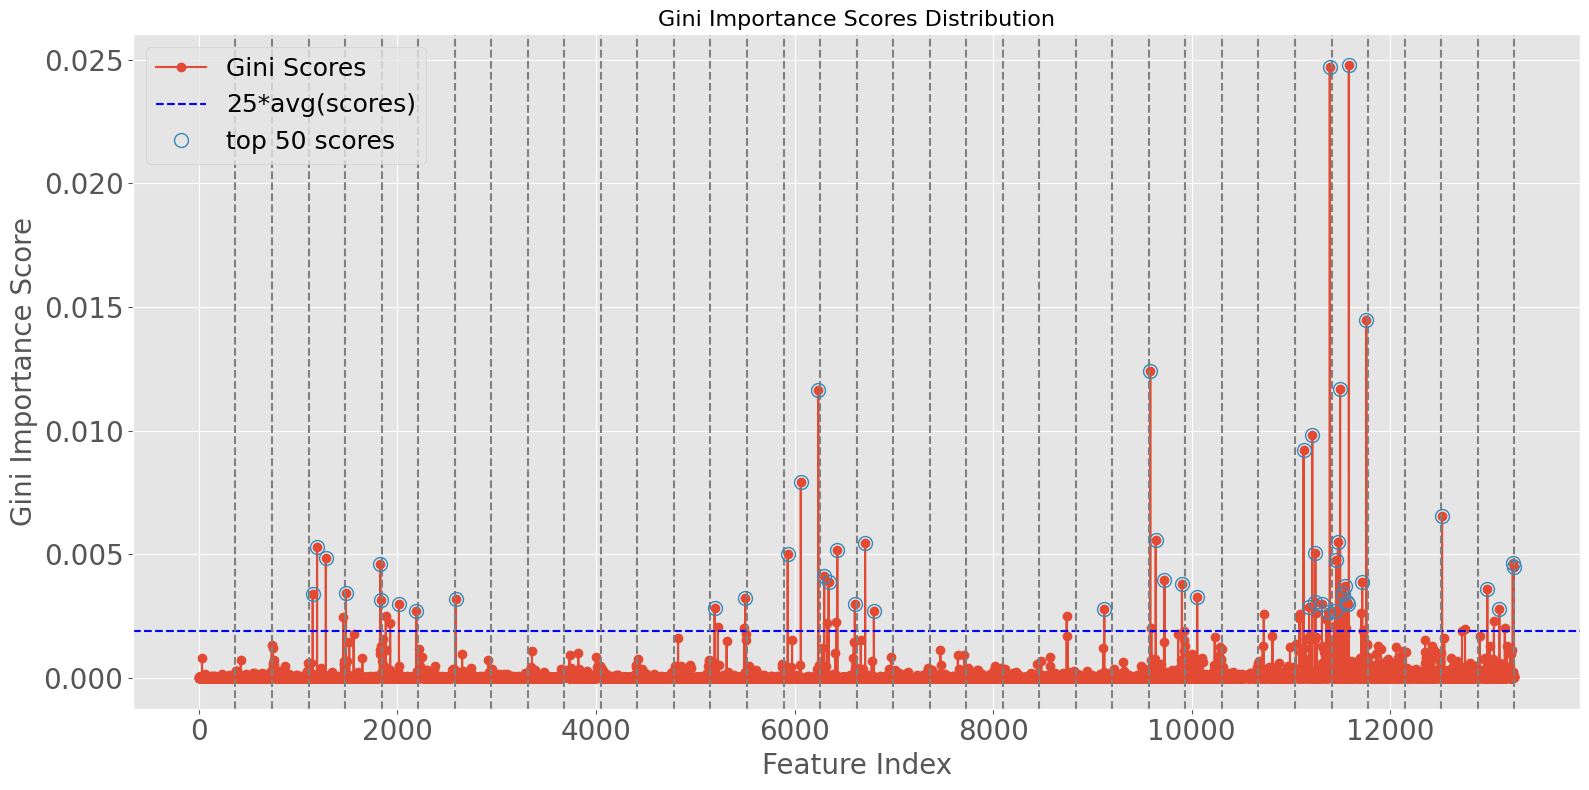

In [5]:
plt.figure(figsize=(16,8))
# plt.plot(idx, scores, marker='o', linestyle='-', markersize=2)
# plt.scatter(idx, scores, s=15)
plt.plot(scores, "-o", label="Gini Scores")
plt.axhline(25*np.mean(scores), color="blue", linestyle='--', label="25*avg(scores)")
# plt.axvline(vertic, color="gray", linestyle='--', label="sensor limit")
for i in range(36):
  plt.axvline(368*(i+1), color="gray", linestyle='--')
plt.plot(
    idx[:50],
    np.sort(scores)[::-1][:50],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 50 scores"
)
plt.title("Gini Importance Scores Distribution", fontsize=16)
plt.xlabel("Feature Index", fontsize=20)
plt.ylabel("Gini Importance Score", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
# plt.savefig("gini_importance_distributionn.png", dpi=300)
# plt.close()
plt.show()

In [87]:
# all_indices = []
all_scores = []
for i in range(36):
  # indices = idx[(i)*368:(i+1)*368]
  score = scores[(i)*368:(i+1)*368]
  # print(indices)
  # all_indices.append(indices)
  all_scores.append(score)
# all_indices = np.array(all_indices)
all_scores = np.array(all_scores)

In [88]:
len(np.sum(all_scores, axis=0))

368

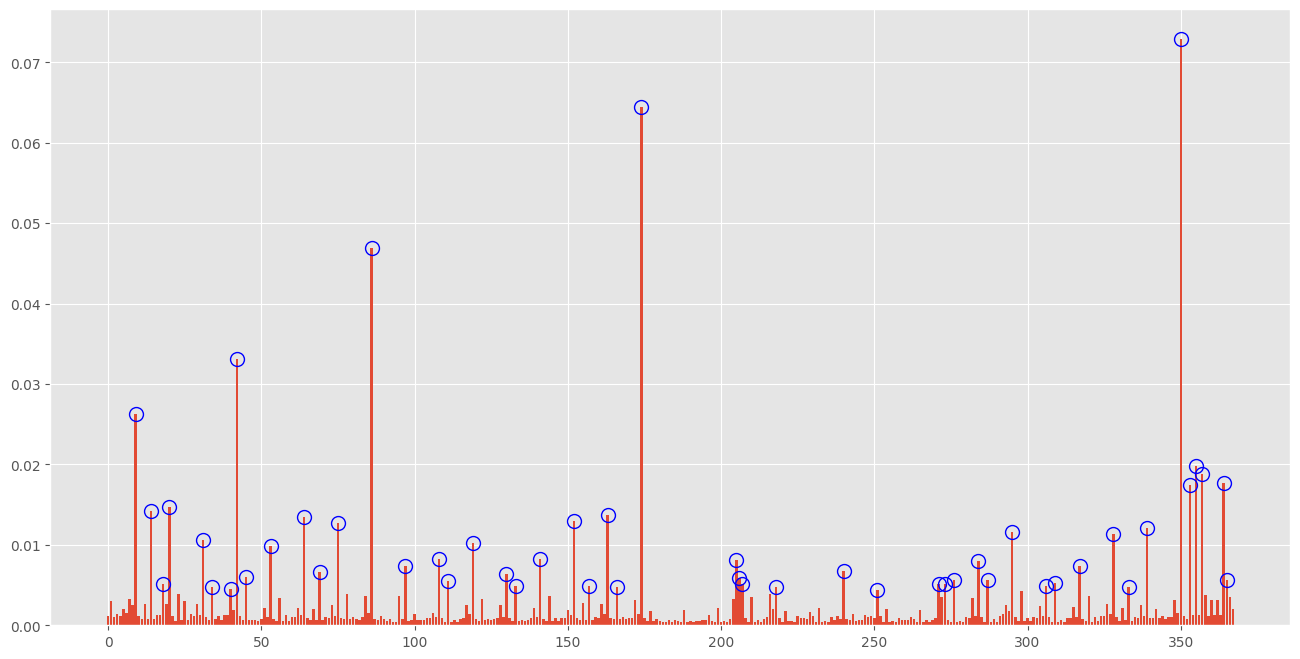

In [89]:
plt.figure(figsize=(16,8))

plt.bar(np.arange(368), np.sum(all_scores, axis=0), label="Gini Scores")

plt.plot(
    np.argsort(np.sum(all_scores, axis=0))[::-1][:50],
    np.sort(np.sum(all_scores, axis=0))[::-1][:50],
    'o',
    markersize=10,
    markeredgewidth=1,
    markerfacecolor='none',
    label="top 50 scores",
    color='blue'
)

plt.show()

per sensor scores

In [45]:
import pandas as pd

f_values= np.linspace(1000, 50000, 36)
df = pd.DataFrame()
df["indices"] = np.arange(368)
for i, f in enumerate(f_values):
  df[f"scores_{int(f)}"] = scores[(i)*368:(i+1)*368]

In [46]:
df.describe()

,indices,scores_1000,scores_2400,scores_3800,scores_5200,scores_6600,scores_8000,scores_9400,scores_10800,scores_12200,...,scores_37400,scores_38800,scores_40200,scores_41600,scores_43000,scores_44400,scores_45800,scores_47200,scores_48600,scores_50000
count,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,...,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000
mean,183.500000,0.000024,0.000048,0.000044,0.000085,0.000077,0.000073,0.000042,0.000042,0.000028,...,0.000148,0.000092,0.000049,0.000079,0.000314,0.000359,0.000108,0.000101,0.000096,0.000124
std,106.376689,0.000046,0.000094,0.000100,0.000436,0.000375,0.000293,0.000095,0.000179,0.000034,...,0.000792,0.000257,0.000058,0.000201,0.001542,0.001723,0.000184,0.000187,0.000386,0.000468
min,0.000000,0.000001,0.000000,0.000010,0.000011,0.000008,0.000008,0.000009,0.000008,0.000007,...,0.000006,0.000007,0.000008,0.000008,0.000008,0.000009,0.000010,0.000010,0.000009,0.000007
25%,91.750000,0.000010,0.000015,0.000016,0.000017,0.000014,0.000014,0.000015,0.000014,0.000014,...,0.000014,0.000017,0.000021,0.000020,0.000023,0.000019,0.000021,0.000020,0.000017,0.000015
50%,183.500000,0.000014,0.000020,0.000021,0.000021,0.000019,0.000020,0.000023,0.000019,0.000019,...,0.000021,0.000026,0.000030,0.000031,0.000039,0.000031,0.000041,0.000034,0.000030,0.000028
75%,275.250000,0.000027,0.000039,0.000029,0.000028,0.000028,0.000033,0.000030,0.000028,0.000029,...,0.000040,0.000045,0.000055,0.000053,0.000117,0.000055,0.000101,0.000108,0.000065,0.000050
max,367.000000,0.000805,0.001325,0.001204,0.005280,0.004623,0.003003,0.001163,0.003184,0.000373,...,0.012405,0.003282,0.000613,0.002577,0.024722,0.024788,0.001297,0.001540,0.006552,0.004666


In [85]:
# select score columns
score_cols = [c for c in df.columns if c.startswith("scores_")]

# mean score per frequency (column-wise)
mean_scores = df[score_cols].mean(axis=0)

# sort from high to low
mean_scores_sorted = mean_scores.sort_values(ascending=False)

# mean_scores_sorted

In [84]:
best_frequencies = mean_scores_sorted.index.str.replace("scores_", "").astype(int)
# best_frequencies

In [83]:
# plt.plot(np.sort(best_frequencies), mean_scores_sorted, "o-")
test_df = pd.DataFrame()
test_df['freq'] = best_frequencies
test_df["mean"] = mean_scores_sorted.values
test_df = test_df.sort_values(by="freq")

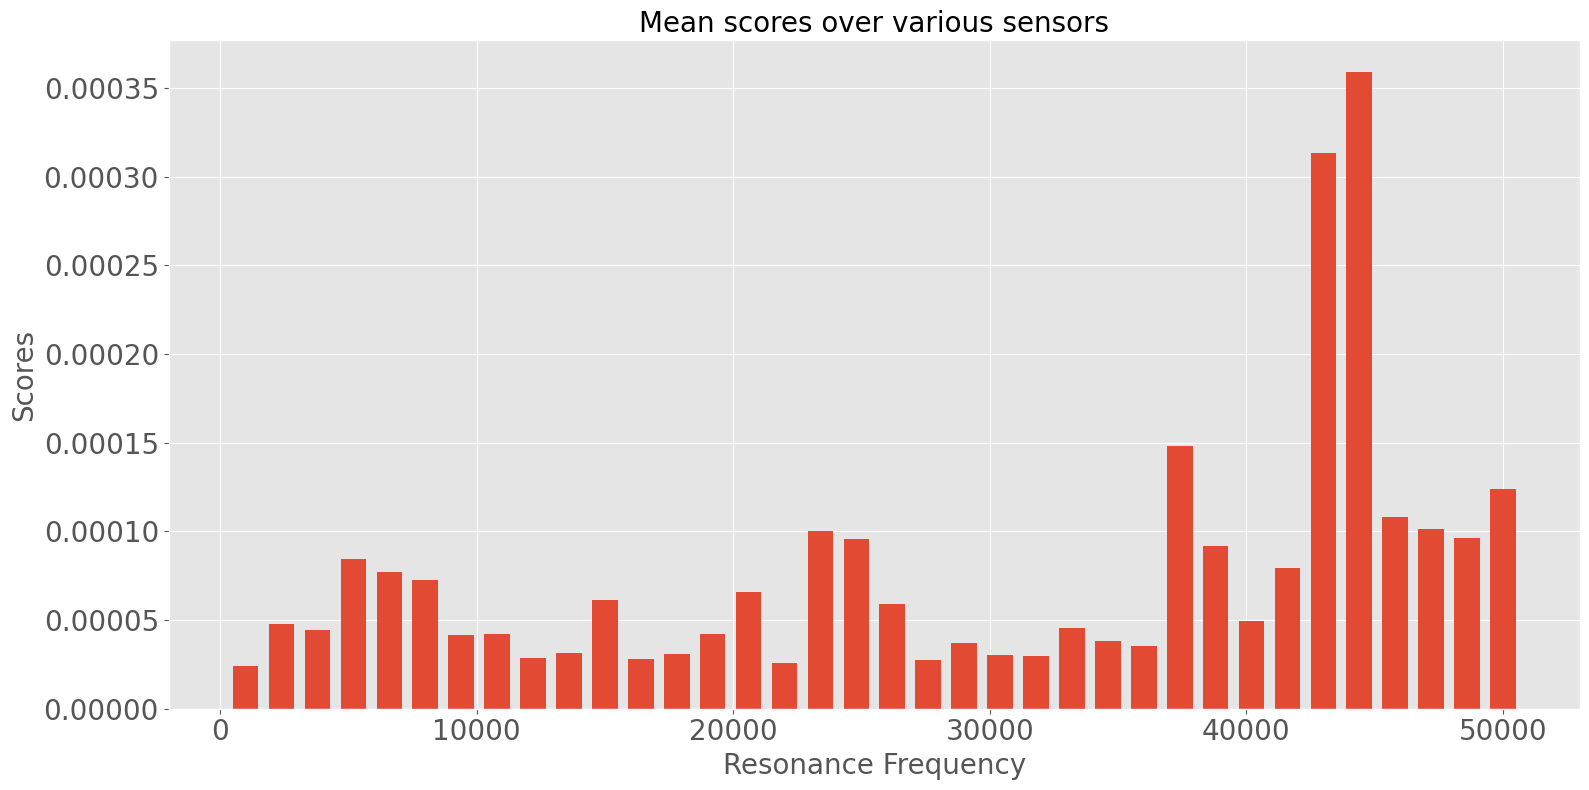

In [82]:
plt.figure(figsize=(16,8))
plt.bar(x=test_df['freq'], height=test_df['mean'], width=1000)
plt.xlabel("Resonance Frequency", fontsize=20)
plt.ylabel("Scores", fontsize=20)
plt.title("Mean scores over various sensors", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()